In [1]:
import os
import yake

kw_extractor = yake.KeywordExtractor(lan="fr", top=50)
kw_extractor



In [2]:
year=1967

TP2 - Partie 1

In [3]:
data_path = '../../data'
txt_path = '../../data/txt'
files = [f for f in os.listdir(txt_path) if os.path.isfile(os.path.join(txt_path, f)) and str(year) in f]
len(files)

100

In [4]:
txt_list = []
for file in files:
    text = open(os.path.join(txt_path, file), 'r', encoding='utf-8').read()
    txt_list.append(text)

In [5]:
keywords_list = []
for text in txt_list: 
    keywords = kw_extractor.extract_keywords(text)
    for k,s in keywords:
        keywords_list.append(k)

print(keywords_list)

['avis tient lieu', 'Madame', 'MONSIEUR', 'Monsieur et Madame', 'avis tient', 'tient lieu', 'Bruxelles', 'avis tient Heu', 'NOVEMBRE', 'présent avis tient', 'MONSIEUR Guillaume EUSSEN', 'Sir Richard', 'rue', 'lieu', 'MADAME VEUVE', 'lieu de faire-part', 'MONSIEUR Henry HALLEZ', 'Madame Henry', 'avis', 'Madame Paul', 'tient', 'Madame Henry MARCELIS', 'faire-part', 'Madame Edgard DETRYVH', 'décès', 'Richard', 'enfants', 'présent avis', 'Madame Jean', 'Madame Jean DEBROUX', 'Madame Paul LIPPENS', 'Madame Jean Gallet', 'MONSIEUR Edgard DETRY', 'prie d’annoncer', 'tient Heu', 'JEAN REY', 'MADAME VEUVE LEON', 'part', 'MADAME Bernard MARCELIS', 'faire part', 'Madame Paul Gallet', 'MADAME VEUVE Joseph', 'MONSIEUR Henry', 'décès de MONSIEUR', 'Madame Veuve Maurice', 'service funèbre', 'faire', 'Madame Antoine', 'cimetière', 'Madame Henry DALLEZ', 'dans', 'conseil communal', 'Magga Dan', 'Conseil', 'Belgique', 'Foire', 'lundi', 'Conseil communal fut', 'ans', 'fut', 'communal', 'Dan', 'pays', 'ch

TP2 - Partie 2 

In [6]:
from collections import Counter
from wordcloud import WordCloud
import os
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from IPython.display import Image

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


In [7]:
sw = stopwords.words("french")
sw += ["les", "plus", "cette", "fait", "faire", "être", "deux", "comme", "dont", "tout",
       "ils", "bien", "sans", "peut", "tous", "après", "ainsi", "donc", "cet", "sous",
       "celle", "entre", "encore", "toutes", "pendant", "moins", "dire", "cela", "non",
       "faut", "trois", "aussi", "dit", "avoir", "doit", "contre", "depuis", "autres",
       "van", "het", "autre", "jusqu", "ville", "rossel", "dem", "très", "ena", "terr", 
       "bur", "trav", "mén", "int", "fem", "culs" "ecr", "cap", "chez", "tel", "conf", 
       "gar", "toute", "tél", "bat", "pers", "mise", "rem", ]
sw = set(sw)

In [8]:
content_list = []
for file in files:
    with open(os.path.join(txt_path, file), 'r', encoding='utf-8') as f:
        content_list.append(f.read())

In [9]:
temp_path = '../../data/tmp'
if not os.path.exists(temp_path):
    os.mkdir(temp_path)
with open(os.path.join(temp_path, f'{year}.txt'), 'w', encoding='utf-8') as f:
    f.write(' '.join(content_list))

In [10]:
def clean_text(year, folder=None):
    if folder is None:
        input_path = f"{year}.txt"
        output_path = f"{year}_clean.txt"
    else:
        input_path = f"{folder}/{year}.txt"
        output_path = f"{folder}/{year}_clean.txt"
    output = open(output_path, "w", encoding='utf-8')
    with open(input_path, 'r', encoding='utf-8') as f:
        text = f.read()
        words = nltk.wordpunct_tokenize(text)
        kept = [w.upper() for w in words if len(w) > 2 and w.isalpha() and w.lower() not in sw]
        kept_string = " ".join(kept)
        output.write(kept_string)
    return f'Output has been written in {output_path}!'

In [11]:
clean_text(year, folder=temp_path)

'Output has been written in ../../data/tmp/1967_clean.txt!'

In [12]:
with open(os.path.join(temp_path, f'{year}_clean.txt'), 'r', encoding='utf-8') as f:
    after = f.read()

In [13]:
frequencies = Counter(after.split())

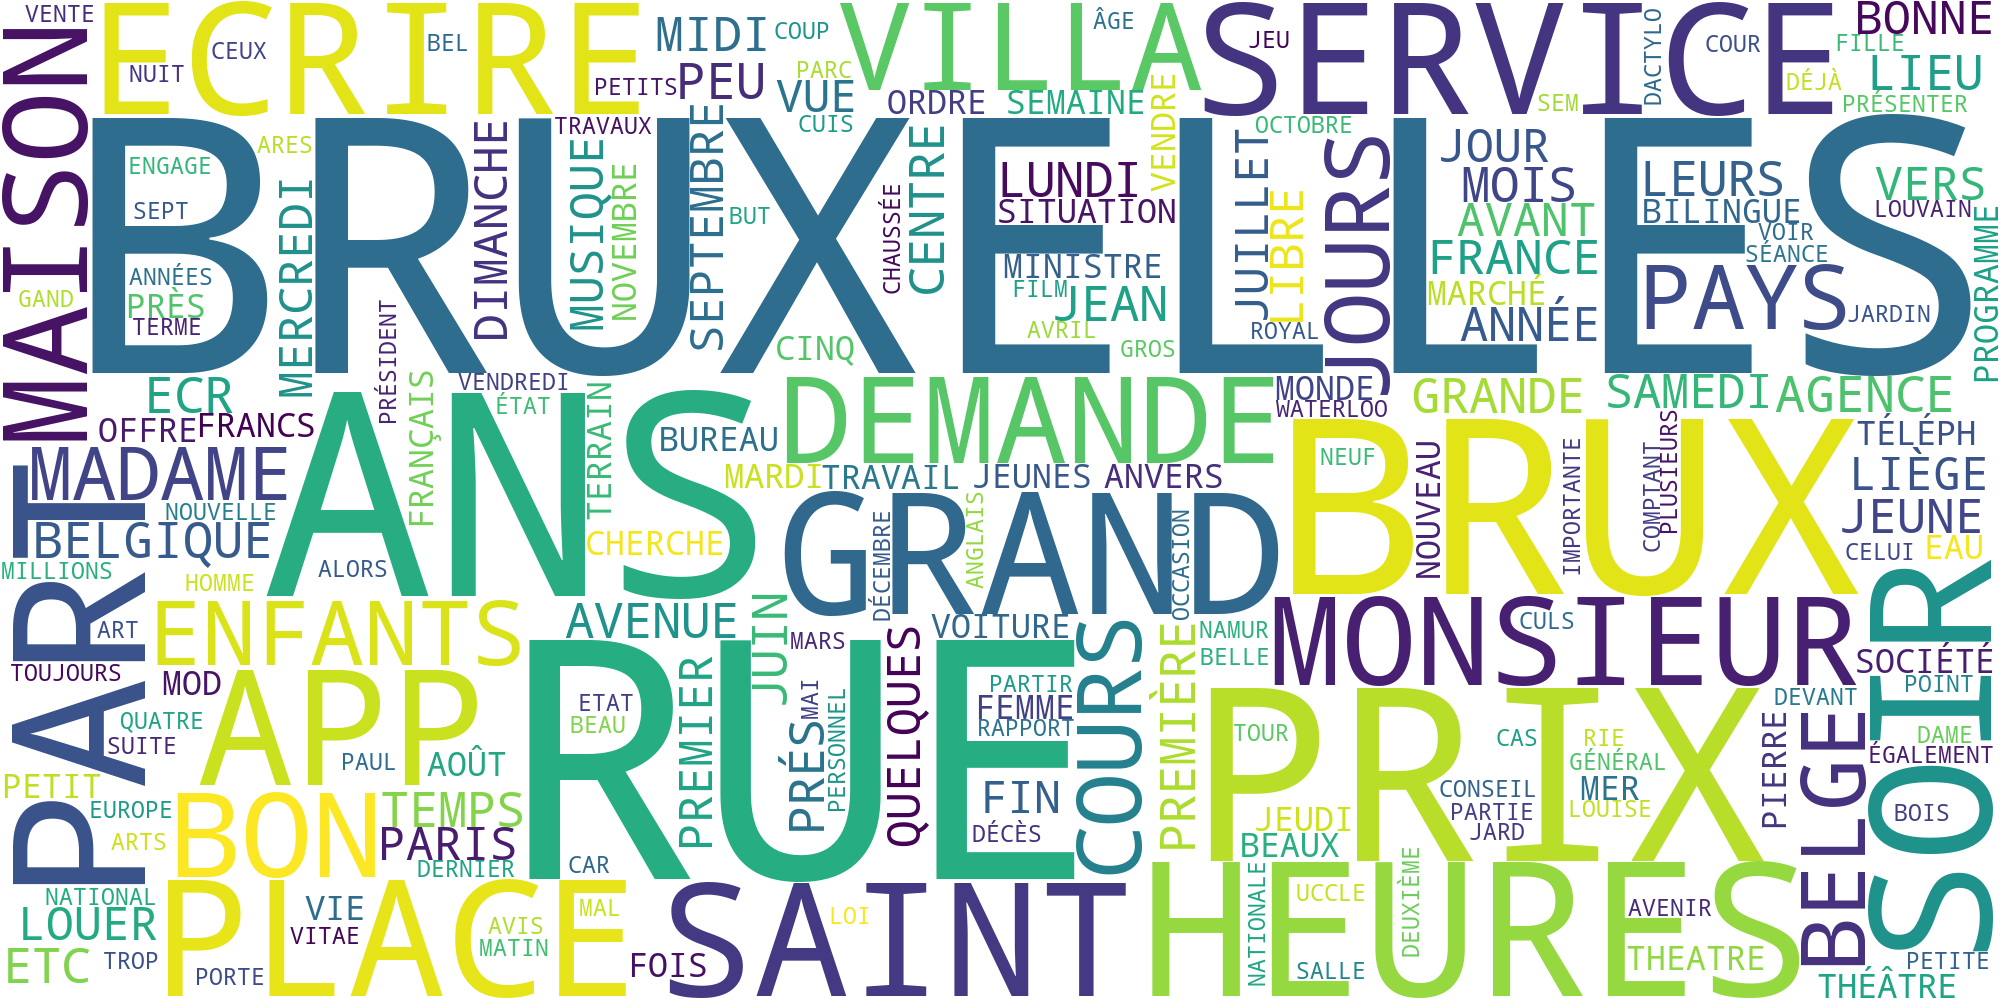

In [14]:
cloud = WordCloud(width=2000, height=1000, background_color='white').generate_from_frequencies(frequencies)
cloud.to_file(os.path.join(temp_path, f"{year}.png"))
Image(filename=os.path.join(temp_path, f"{year}.png"))

TP2 - Partie 3

In [15]:
from collections import defaultdict
import spacy
from spacy.lang.fr.examples import sentences
%pip install  fr_core_news_md

nlp = spacy.load('fr_core_news_md')


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Users/iduoliveira/TACTEST/tac/.venv/lib/python3.11/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'fr_core_news_md' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [16]:
text = open(f"../../data/tmp/{year}.txt", encoding='utf-8').read()[:1000000]

In [17]:
doc = nlp(text)

In [18]:
people = defaultdict(int)
for ent in doc.ents:
    if ent.label_ == "PER" and len(ent.text) > 3:
        people[ent.text] += 1

In [19]:
sorted_people = sorted(people.items(), key=lambda kv: kv[1], reverse=True)

for person, freq in sorted_people[:50]:
    print(f"{person} apparait {freq} fois dans le corpus")

Rossel apparait 65 fois dans le corpus
Monsieur apparait 51 fois dans le corpus
- Tél apparait 30 fois dans le corpus
Simons apparait 23 fois dans le corpus
MONSIEUR apparait 18 fois dans le corpus
François apparait 15 fois dans le corpus
Janssens apparait 13 fois dans le corpus
Sir Richard apparait 11 fois dans le corpus
Schumann apparait 11 fois dans le corpus
Hemming apparait 11 fois dans le corpus
Ag Rossel apparait 10 fois dans le corpus
Napoléon apparait 10 fois dans le corpus
Joël Robert apparait 10 fois dans le corpus
culs apparait 9 fois dans le corpus
Bracke apparait 9 fois dans le corpus
Robert apparait 9 fois dans le corpus
D.CJ apparait 9 fois dans le corpus
Fleming apparait 9 fois dans le corpus
Merckx apparait 9 fois dans le corpus
Louise apparait 8 fois dans le corpus
Ecrire Ag apparait 8 fois dans le corpus
Lino Ventura apparait 8 fois dans le corpus
F. Tél apparait 8 fois dans le corpus
Teeuwissen apparait 8 fois dans le corpus
Philippe apparait 7 fois dans le corpus


TP2 - Partie 4

1/2

In [20]:
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer

In [21]:
tb = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())

def get_sentiment(input_text):
    blob = tb(input_text)
    polarity, subjectivity = blob.sentiment
    polarity_perc = f"{100*abs(polarity):.0f}"
    subjectivity_perc = f"{100*subjectivity:.0f}"
    if polarity > 0:
        polarity_str = f"{polarity_perc}% positive"
    elif polarity < 0:
        polarity_str = f"{polarity_perc}% negative"
    else:
        polarity_str = "neutral"
    if subjectivity > 0:
        subjectivity_str = f"{subjectivity_perc}% subjective"
    else:
        subjectivity_str = "perfectly objective"
    print(f"This text is {polarity_str} and {subjectivity_str}.")

In [22]:
sentences = ["Les ouvrières se rendaient chaque soir à la soupe populaire, où l’on distribuait du pain et un repas chaud aux familles nécessiteuses.",
             "Les voyageurs furent installés dans une vaste salle commune, sur des couchettes de bois recouvertes de couvertures grossières.",
             "Le Prince, retenu au palais par une indisposition légère, fit savoir qu’il regrettait de ne pouvoir assister à la représentation.",
             "Le ministère envisageait de supprimer plusieurs postes administratifs afin de réduire les dépenses de l’État.",
             "Il nous reste encore bien des obstacles à surmonter avant de pouvoir considérer cette affaire comme définitivement réglée.",
             "Malgré le froid glacial et la pluie battante, les deux hommes retirèrent leurs manteaux et se préparèrent au combat.",
             "À vrai dire, personne dans le quartier ne considérait cet homme comme véritablement dangereux, malgré la gravité de son crime.",
             "Il avait autrefois servi dans les armées du roi et participé à plusieurs batailles aux frontières du royaume.",
             "Depuis quelques jours, toute la bourgeoisie ne parle que d’un scandale survenu dans une maison respectable du centre-ville.",
             "Aucun souverain de son époque ne fut aussi fréquemment exposé aux complots, aux menaces et aux tentatives d’assassinat."]

In [23]:
for s in sentences: 
    get_sentiment(s) 

This text is 38% positive and 38% subjective.
This text is 25% positive and 38% subjective.
This text is 18% positive and 20% subjective.
This text is neutral and perfectly objective.
This text is neutral and 20% subjective.
This text is 14% negative and 14% subjective.
This text is 10% negative and 40% subjective.
This text is 20% negative and 10% subjective.
This text is 22% positive and 10% subjective.
This text is neutral and perfectly objective.


2/2

In [24]:
import os
os.environ['USE_TF'] = '0'
os.environ['USE_TORCH'] = '1'

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

tokenizer = AutoTokenizer.from_pretrained('visalkao/sentiment-analysis-french')
model = AutoModelForSequenceClassification.from_pretrained('visalkao/sentiment-analysis-french')

sentiment_analyser = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Device set to use mps:0


In [25]:
for s in sentences:
    print(sentiment_analyser(s))

[{'label': 'POSITIF', 'score': 0.9252332448959351}]
[{'label': 'NEGATIF', 'score': 0.9960969090461731}]
[{'label': 'NEGATIF', 'score': 0.9468632340431213}]
[{'label': 'NEGATIF', 'score': 0.6152087450027466}]
[{'label': 'NEGATIF', 'score': 0.8379644155502319}]
[{'label': 'POSITIF', 'score': 0.7793411016464233}]
[{'label': 'NEGATIF', 'score': 0.9953645467758179}]
[{'label': 'POSITIF', 'score': 0.9795271754264832}]
[{'label': 'NEGATIF', 'score': 0.9914649128913879}]
[{'label': 'POSITIF', 'score': 0.9922032356262207}]
